# Capítulo 15 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 15. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Cp, Lv, Lf = 9.8, 1004.0, 2.5e6, 3.34e5
rho_ar, rho_gelo, rho_agua = 1.0, 900.0, 1000.0

## T1 — $w_T \propto \sqrt{D}$ do granizo

In [2]:
# peso = arrasto: rho_i g (pi/6) D^3 = Cd rho_ar (pi/8) D^2 wT^2
D_, Cd_, ri_, ra_, g_ = sp.symbols('D C_d rho_i rho_a g', positive=True)
wT = sp.solve(sp.Eq(ri_*g_*sp.pi/6*D_**3, Cd_*ra_*sp.pi/8*D_**2*sp.Symbol('w', positive=True)**2),
              sp.Symbol('w', positive=True))[0]
display(sp.Eq(sp.Symbol('w_T'), sp.simplify(wT)))
f_num = sp.lambdify(D_, wT.subs({Cd_: 0.55, ri_: 900.0, ra_: 1.0, g_: 9.8}))
for d_cm in [1, 2.5, 5, 10]:
    print(f'D = {d_cm:4.1f} cm: w_T = {f_num(d_cm/100):5.1f} m/s')
print('\nA raiz de D vem do balanço volume (D³) × área (D²): dobrar a pedra')
print('so exige ~40% mais updraft — mas 40% de 30 m/s so existe em supercelula.')

Eq(w_T, 2*sqrt(3)*sqrt(D)*sqrt(g)*sqrt(rho_i)/(3*sqrt(C_d)*sqrt(rho_a)))

D =  1.0 cm: w_T =  14.6 m/s
D =  2.5 cm: w_T =  23.1 m/s
D =  5.0 cm: w_T =  32.7 m/s
D = 10.0 cm: w_T =  46.2 m/s

A raiz de D vem do balanço volume (D³) × área (D²): dobrar a pedra
so exige ~40% mais updraft — mas 40% de 30 m/s so existe em supercelula.


## T2 — DCAPE

**Solução.** Espelho do CAPE: uma parcela de downdraft, mantida saturada pela evaporação da chuva, desce pela adiabática úmida a partir do nível de origem $z_0$; o ambiente é mais quente. O trabalho do empuxo negativo acumulado é
$$\mathrm{DCAPE} = \int_{0}^{z_0} g\,\frac{T_{v,e} - T_{v,p}}{T_{v,e}}\,dz > 0,\qquad w_{down} = \sqrt{2\,\mathrm{DCAPE}}.$$
A parcela desce pelo $\theta_w$ dela (Cap. 4): quanto mais seca a camada sub-nuvem, mais a evaporação segura a parcela fria em relação ao ambiente e maior o DCAPE — valores típicos de 500–1500 J/kg dão rajadas de 30–55 m/s. ∎

## T3 — Flash-to-bang e a energia do raio

In [3]:
# som: c_s = sqrt(gamma R T) ~ 343 m/s a 20 °C; luz: instantânea.
cs = np.sqrt(1.4*287*293)
print(f'c_som = {cs:.0f} m/s -> {1000/cs:.1f} s por km: a regra dos ~3 s por km')
print('(conte os segundos entre o clarao e o trovao e divida por 3: distancia em km).')
print()
# energia: corrente de pico ~30 kA, ddp ~100 MV, duração efetiva ~100 us x varios strokes
Q, V = 5.0, 1e8                                # ~5 C transferidos, ~100 MV
print(f'E ~ Q*V ~ {Q*V/1e9:.1f} GJ por raio — aquece o canal a ~30 000 K,')
print('5x a superficie do Sol: dai o trovao (expansao supersonica do canal).')

c_som = 343 m/s -> 2.9 s por km: a regra dos ~3 s por km
(conte os segundos entre o clarao e o trovao e divida por 3: distancia em km).

E ~ Q*V ~ 0.5 GJ por raio — aquece o canal a ~30 000 K,
5x a superficie do Sol: dai o trovao (expansao supersonica do canal).


## T4 — Queda de pressão do Rankine

In [4]:
# ciclostrófico dP/dr = rho v²/r com Rankine: núcleo v = vm r/R, fora v = vm R/r
r_, R_, vm, rho_ = sp.symbols('r R v_m rho', positive=True)
dP_fora = sp.integrate(rho_*(vm*R_/r_)**2/r_, (r_, R_, sp.oo))
dP_nucleo = sp.integrate(rho_*(vm*r_/R_)**2/r_, (r_, 0, R_))
total = sp.simplify(dP_fora + dP_nucleo)
display(sp.Eq(sp.Symbol('Delta_P'), total))
print('Metade da queda vem de fora do núcleo, metade de dentro: ΔP = ρ v_max².')
for v in [40, 70, 110]:
    print(f'v_max = {v:3d} m/s: ΔP = {1.0*v**2/100:5.1f} hPa')

Eq(Delta_P, rho*v_m**2)

Metade da queda vem de fora do núcleo, metade de dentro: ΔP = ρ v_max².
v_max =  40 m/s: ΔP =  16.0 hPa
v_max =  70 m/s: ΔP =  49.0 hPa
v_max = 110 m/s: ΔP = 121.0 hPa


## T5 — Pressão dinâmica e a escala EF

In [5]:
# força por área ~ q = 0.5 rho v² (pressão dinâmica de estagnação)
# limiares OFICIAIS da escala EF (rajada de 3 s, limite inferior de cada categoria):
print('carga de vento q = ½ρv² (por m² de parede exposta), nos limiares EF:')
for ef, v in [('EF0', 29), ('EF1', 38), ('EF2', 50), ('EF3', 61),
              ('EF4', 74), ('EF5', 89)]:
    q = 0.5*1.0*v**2
    print(f'{ef} (v ≥ {v:3d} m/s): q = {q/1000:5.1f} kPa = {q:6.0f} N/m²'
          f'  (~{q/9.8:5.0f} kgf/m²)')
print()
print('EF5 no limiar (89 m/s): ~4 kPa — quase meia tonelada-força por m²; e')
print('picos medidos por radar passam de 110 m/s (~6 kPa). Como q ~ v², dobrar')
print('o vento quadruplica a carga: a nao-linearidade que a escala EF captura.')

carga de vento q = ½ρv² (por m² de parede exposta), nos limiares EF:
EF0 (v ≥  29 m/s): q =   0.4 kPa =    420 N/m²  (~   43 kgf/m²)
EF1 (v ≥  38 m/s): q =   0.7 kPa =    722 N/m²  (~   74 kgf/m²)
EF2 (v ≥  50 m/s): q =   1.2 kPa =   1250 N/m²  (~  128 kgf/m²)
EF3 (v ≥  61 m/s): q =   1.9 kPa =   1860 N/m²  (~  190 kgf/m²)
EF4 (v ≥  74 m/s): q =   2.7 kPa =   2738 N/m²  (~  279 kgf/m²)
EF5 (v ≥  89 m/s): q =   4.0 kPa =   3960 N/m²  (~  404 kgf/m²)

EF5 no limiar (89 m/s): ~4 kPa — quase meia tonelada-força por m²; e
picos medidos por radar passam de 110 m/s (~6 kPa). Como q ~ v², dobrar
o vento quadruplica a carga: a nao-linearidade que a escala EF captura.


---
## N1 — Derretimento na queda

z_cong = 3 km: chega ao chao (>1 mm) se D0 > 1.6 cm


z_cong = 4 km: chega ao chao (>1 mm) se D0 > 2.3 cm


z_cong = 5 km: chega ao chao (>1 mm) se D0 > 3.0 cm


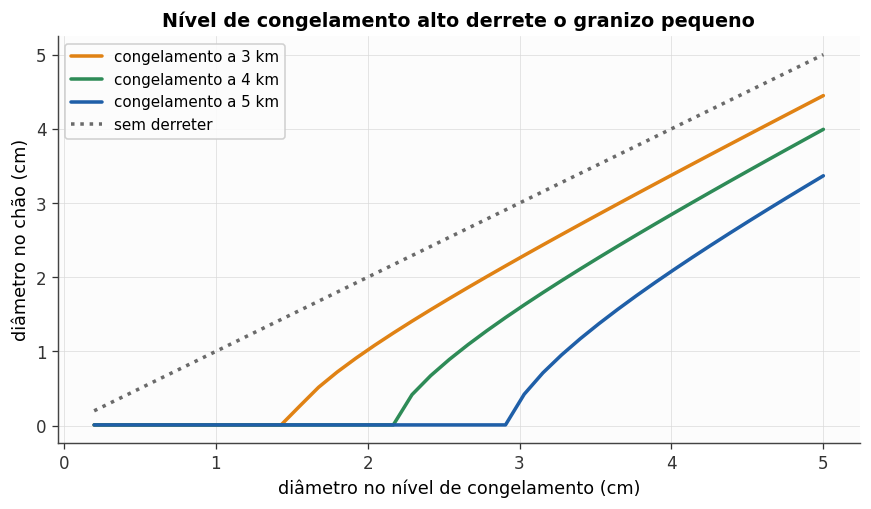

por isso granizo e mais comum em massas frias/subtropicais que no equador,
apesar da conveccao tropical vigorosa: la o forno de 5 km derrete quase tudo.


In [6]:
Cd, k_melt = 0.55, 6e-6                        # taxa efetiva de derretimento (m/s por K)
gamma_amb = 6.5e-3

def diametro_final(D0, z_cong):
    def rhs(t, y):
        z, D = y
        if D <= 1e-4:
            return [0.0, 0.0]
        wT = np.sqrt(4*g*rho_gelo*D/(3*Cd*rho_ar))
        dT = gamma_amb*max(z_cong - z, 0)      # excesso térmico abaixo do congelamento
        return [-wT, -k_melt*dT]
    def chao(t, y):
        return y[0]
    chao.terminal, chao.direction = True, -1
    s = solve_ivp(rhs, [0, 4000], [z_cong, D0], events=chao, rtol=1e-8)
    return max(s.y[1][-1], 0.0)

D0s = np.linspace(0.002, 0.05, 40)
fig, ax = plt.subplots(figsize=(9, 4.6))
for zc, cor in [(3000, CORES['laranja']), (4000, CORES['verde']), (5000, CORES['azul'])]:
    Df = [diametro_final(D0, zc)*100 for D0 in D0s]
    ax.plot(D0s*100, Df, color=cor, label=f'congelamento a {zc/1e3:.0f} km')
    i = np.argmax(np.array(Df) > 0.1)
    print(f'z_cong = {zc/1e3:.0f} km: chega ao chao (>1 mm) se D0 > {D0s[i]*100:.1f} cm')
ax.plot(D0s*100, D0s*100, ':', color=CORES['cinza'], label='sem derreter')
ax.set(xlabel='diâmetro no nível de congelamento (cm)', ylabel='diâmetro no chão (cm)',
       title='Nível de congelamento alto derrete o granizo pequeno')
ax.legend()
plt.show()
print('por isso granizo e mais comum em massas frias/subtropicais que no equador,')
print('apesar da conveccao tropical vigorosa: la o forno de 5 km derrete quase tudo.')

## N2 — Downburst × umidade sub-nuvem

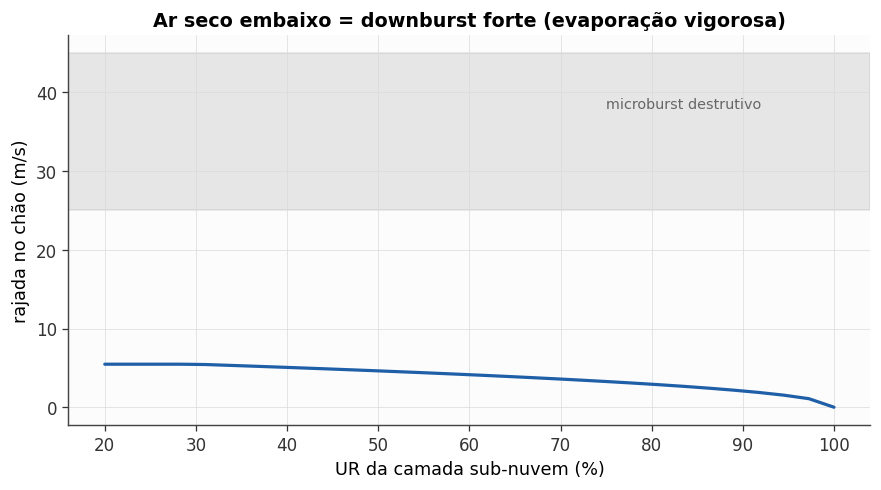

o downburst SECO cai de nuvem inofensiva (virga, pouca chuva no radar):
traicoeiro para aviacao — o eco fraco esconde a rajada de 30+ m/s.


In [7]:
theta0, z_base = 302.0, 3000.0

def rajada(deficit_K):
    def rhs(t, y):
        z, w = y
        B = -g*deficit_K*np.clip(z/z_base, 0, 1)/theta0
        return [w, B - 1.2e-3*abs(w)*w]
    def chao(t, y): return y[0]
    chao.terminal, chao.direction = True, -1
    s = solve_ivp(rhs, [0, 3000], [z_base, 0.0], events=chao, rtol=1e-8)
    return abs(s.y[1][-1])

URs = np.linspace(20, 100, 30)
deficits = 8.0*np.clip((100 - URs)/70, 0, 1)   # máx 8 K quando UR<=30%
vs = [rajada(dk) for dk in deficits]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(URs, vs, color=CORES['azul'], lw=2)
ax.axhspan(25, 45, color=CORES['cinza'], alpha=0.15)
ax.text(75, 38, 'microburst destrutivo', fontsize=9, color='#666666')
ax.set(xlabel='UR da camada sub-nuvem (%)', ylabel='rajada no chão (m/s)',
       title='Ar seco embaixo = downburst forte (evaporação vigorosa)')
plt.show()
print('o downburst SECO cai de nuvem inofensiva (virga, pouca chuva no radar):')
print('traicoeiro para aviacao — o eco fraco esconde a rajada de 30+ m/s.')

## N3 — Updraft carrega o capacitor

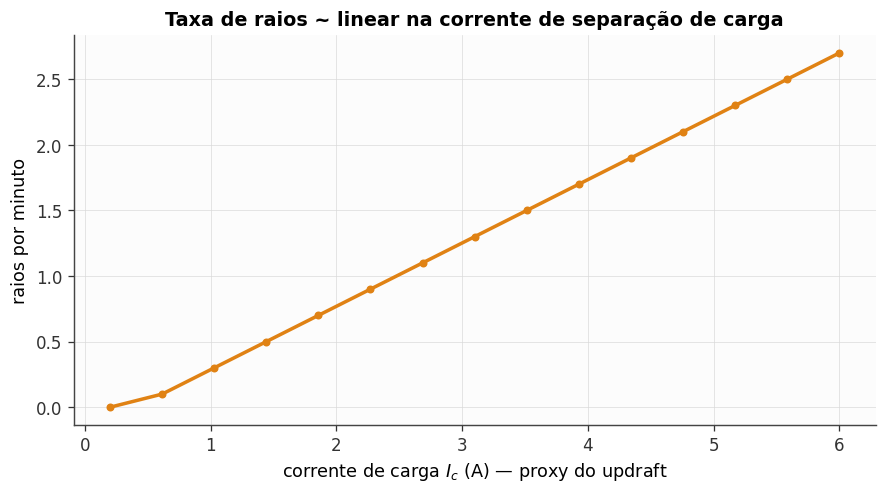

no modelo RC a taxa e ~linear em I_c; na natureza I_c cresce brutalmente
com w (colisoes graupel-cristal ~ fluxo de massa gelada ~ w³ ou mais),
compondo a famosa sensibilidade ~w^6 da taxa de relampagos.


In [8]:
C_nuvem, R_fuga, E_rup, d = 0.1e-6, 5e9, 3e5, 5000.0
Q_rup = E_rup*d*C_nuvem

def taxa_raios(I_c, T_tot=600.0):
    raios, t_now, Q0 = 0, 0.0, 0.0
    while t_now < T_tot:
        def rompe(t, Q): return Q[0] - Q_rup
        rompe.terminal, rompe.direction = True, 1
        s = solve_ivp(lambda t, Q: [I_c - Q[0]/(R_fuga*C_nuvem)],
                      [t_now, T_tot], [Q0], events=rompe, max_step=1.0)
        if s.t_events[0].size:
            raios += 1; t_now = s.t_events[0][0]; Q0 = 0.15*Q_rup
        else:
            break
    return raios/(T_tot/60)

Is = np.linspace(0.2, 6, 15)
taxas = [taxa_raios(I) for I in Is]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(Is, taxas, 'o-', ms=4, color=CORES['laranja'])
ax.set(xlabel='corrente de carga $I_c$ (A) — proxy do updraft',
       ylabel='raios por minuto',
       title='Taxa de raios ~ linear na corrente de separação de carga')
plt.show()
print('no modelo RC a taxa e ~linear em I_c; na natureza I_c cresce brutalmente')
print('com w (colisoes graupel-cristal ~ fluxo de massa gelada ~ w³ ou mais),')
print('compondo a famosa sensibilidade ~w^6 da taxa de relampagos.')

## N4 — Tornado que anda

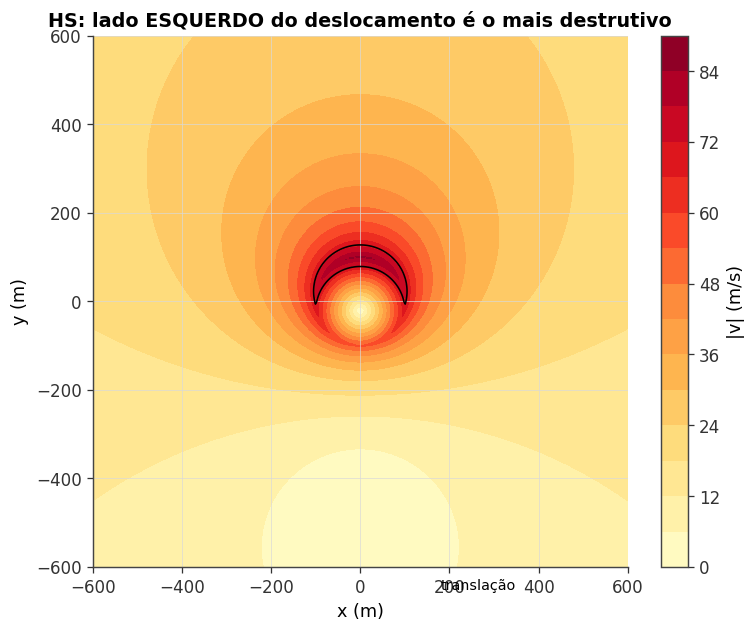

pico de 85 m/s no lado esquerdo (y>0) da trajetoria:
giro horario (HS) + translacao somam-se a esquerda do deslocamento —
espelho do HN, onde o lado direito e o perigoso.


In [9]:
vmax, R0, U_trans = 70.0, 100.0, 15.0          # EF3 transladando
x = np.linspace(-600, 600, 400); y = np.linspace(-600, 600, 400)
X, Y = np.meshgrid(x, y)
r = np.hypot(X, Y)
vt = np.where(r <= R0, vmax*r/R0, vmax*R0/np.maximum(r, 1))
# HS: giro HORÁRIO -> componentes (sentido -phi)
u = vt*Y/np.maximum(r, 1) + U_trans            # translação para +x
v = -vt*X/np.maximum(r, 1)
vel = np.hypot(u, v)

fig, ax = plt.subplots(figsize=(7.5, 6))
cf = ax.contourf(X, Y, vel, levels=15, cmap='YlOrRd')
ax.contour(X, Y, vel, levels=[vmax], colors='k', linewidths=1)
ax.annotate('', xy=(500, -680), xytext=(100, -680),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(180, -650, 'translação', fontsize=9)
ax.set(xlabel='x (m)', ylabel='y (m)', title='HS: lado ESQUERDO do deslocamento é o mais destrutivo')
fig.colorbar(cf, label='|v| (m/s)')
plt.show()
i, j = np.unravel_index(np.argmax(vel), vel.shape)
lado = 'esquerdo (y>0)' if Y[i, j] > 0 else 'direito (y<0)'
print(f'pico de {vel.max():.0f} m/s no lado {lado} da trajetoria:')
print('giro horario (HS) + translacao somam-se a esquerda do deslocamento —')
print('espelho do HN, onde o lado direito e o perigoso.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*